In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import warnings
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, RobustScaler, FunctionTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SequentialFeatureSelector
from scipy.stats import loguniform, uniform, randint
import math

from sklearn.linear_model import (
    LinearRegression, LogisticRegression, Ridge, Lasso, 
    ElasticNet, Lars, BayesianRidge
)
from sklearn.metrics import r2_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', None)

## Data Wrangling

### Carga de Datos

In [2]:
df = pd.read_csv("data/GBvideos.csv", header=0)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7993 entries, 0 to 7992
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   video_id        7993 non-null   object 
 1   title           7993 non-null   object 
 2   channel_title   7993 non-null   object 
 3   category_id     7993 non-null   int64  
 4   tags            7993 non-null   object 
 5   views           7993 non-null   int64  
 6   likes           7993 non-null   int64  
 7   dislikes        7993 non-null   int64  
 8   comment_total   7993 non-null   int64  
 9   thumbnail_link  7993 non-null   object 
 10  date            7993 non-null   float64
dtypes: float64(1), int64(5), object(5)
memory usage: 687.0+ KB


In [4]:
df.shape

(7993, 11)

### EDA

In [5]:
df.head()

,video_id,title,channel_title,category_id,tags,views,likes,dislikes,comment_total,thumbnail_link,date
0,jt2OHQh0HoQ,"Live Apple Event - Apple September Event 2017 - iPhone 8, iPhone X, iOS 11 - Apple Keynote",Apple Event,28,apple events|apple event|iphone 8|iphone x|iphone 8 plus|iphone 7s|iphone 7s plus|ios 11,7426393,78240,13548,705,https://i.ytimg.com/vi/jt2OHQh0HoQ/default_live.jpg,13.09
1,AqokkXoa7uE,Holly and Phillip Meet Samantha the Sex Robot | This Morning,This Morning,24,this morning|interview|holly willoughby|phillip schofield|ruth langsford|eamonn holmes|chat shows - topic|chat show - topic|talk shows - topic|sex robot|samantha|real life,494203,2651,1309,0,https://i.ytimg.com/vi/AqokkXoa7uE/default.jpg,13.09
2,YPVcg45W0z4,My DNA Test Results! I'm WHAT?!,emmablackery,24,emmablackery|emma blackery|emma|blackery|british vlogger|british youtuber|female vlogger|birdyboots|dna test|23andme|ancestry,142819,13119,151,1141,https://i.ytimg.com/vi/YPVcg45W0z4/default.jpg,13.09
3,T_PuZBdT2iM,getting into a conversation in a language you don't actually speak that well,ProZD,1,skit|korean|language|conversation|esl|japanese|foreign|communication|don't speak|struggle|foreigner|lotte mart|korea|south|weather|good|tutorial,1580028,65729,1529,3598,https://i.ytimg.com/vi/T_PuZBdT2iM/default.jpg,13.09
4,NsjsmgmbCfc,Baby Name Challenge!,Sprinkleofglitter,26,sprinkleofglitter|sprinkle of glitter|baby glitter|Louise Pentland|Louise Pentland Baby Name|Mrs Meldrum|Baby Names|Nice baby names|Unusual baby names,40592,5019,57,490,https://i.ytimg.com/vi/NsjsmgmbCfc/default.jpg,13.09


In [6]:
df.describe()

,category_id,views,likes,dislikes,comment_total,date
count,7993.000000,7.993000e+03,7.993000e+03,7993.000000,7993.000000,7993.000000
mean,19.738271,1.110733e+06,3.885966e+04,1528.858877,4991.631177,16.088874
std,7.178132,3.048740e+06,1.092951e+05,8176.707788,26837.135518,7.678176
min,1.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,1.100000
25%,17.000000,1.083750e+05,2.580000e+03,71.000000,308.000000,10.100000
50%,23.000000,3.151940e+05,9.561000e+03,249.000000,1038.000000,16.100000
75%,24.000000,9.712210e+05,3.159300e+04,867.000000,3327.000000,21.100000
max,29.000000,5.896141e+07,2.289911e+06,192725.000000,813322.000000,30.090000


In [7]:
df.isnull().sum()

video_id          0
title             0
channel_title     0
category_id       0
tags              0
views             0
likes             0
dislikes          0
comment_total     0
thumbnail_link    0
date              0
dtype: int64

In [8]:
def auditar_datos(df):
    
    # 1. Verificaciones Generales
    print("--- Resumen General ---")
    print(f"Total de Filas: {df.shape[0]}")
    print(f"Total de Columnas: {df.shape[1]}")
    print(f"Duplicados Exactos: {df.duplicated().sum()}")
    print(f"Memoria Usada: {df.memory_usage().sum() / 1024**2:.2f} MB")
    print("-" * 25)

    audit = pd.DataFrame(index=df.columns)

    audit['Tipo de Dato'] = df.dtypes
    audit['Conteo'] = df.count()
    audit['Nulos'] = df.isnull().sum()
    audit['% Nulos'] = (df.isnull().mean() * 100).round(2)
    audit['Ceros (0)'] = (df == 0).sum()
    audit['Únicos'] = df.nunique()
    audit['% Únicos'] = (df.nunique() / df.shape[0] * 100).round(2)
    
    audit['Memoria (KB)'] = (df.memory_usage(deep=True)[df.columns] / 1024).round(2)

    top_vals = []
    top_freqs = []
    
    for col in df.columns:
        try:
            val_counts = df[col].value_counts()
            if not val_counts.empty:
                top_vals.append(val_counts.index[0])
                top_freqs.append(val_counts.iloc[0])
            else:
                top_vals.append(np.nan)
                top_freqs.append(0)
        except Exception:
            top_vals.append(np.nan)
            top_freqs.append(0)

    audit['Top Valor'] = top_vals
    audit['Frecuencia Top'] = top_freqs


    return audit.sort_values(by='% Nulos', ascending=False)


def auditar_unarias(df):
    columnas_unarias = [col for col in df.columns if df[col].nunique(dropna=False) == 1]
    return columnas_unarias

def auditar_baja_representatividad(df, umbral=0.05):
    reporte = []
    
    cols_categ = df.select_dtypes(include=['object', 'category']).columns
    
    for col in cols_categ:
        frecuencias = df[col].value_counts(normalize=True)
        bajos = frecuencias[frecuencias < umbral]
        
        for valor, frec in bajos.items():
            reporte.append({
                'Columna': col,
                'Valor_Raro': valor,
                'Frecuencia_Pct': f"{frec*100:.2f}%"
            })
            
    if not reporte:
        return pd.DataFrame(columns=['Columna', 'Valor_Raro', 'Frecuencia_Pct'])
        
    return pd.DataFrame(reporte).sort_values(by=['Columna', 'Frecuencia_Pct'])

In [9]:
resultado = auditar_datos(df)
print(resultado)

--- Resumen General ---
Total de Filas: 7993
Total de Columnas: 11
Duplicados Exactos: 0
Memoria Usada: 0.67 MB
-------------------------
               Tipo de Dato  Conteo  Nulos  % Nulos  Ceros (0)  Únicos  \
video_id             object    7993      0      0.0          0    1736   
title                object    7993      0      0.0          0    1771   
channel_title        object    7993      0      0.0          0    1003   
category_id           int64    7993      0      0.0          0      15   
tags                 object    7993      0      0.0          0    1631   
views                 int64    7993      0      0.0          9    7957   
likes                 int64    7993      0      0.0         64    6841   
dislikes              int64    7993      0      0.0        111    2350   
comment_total         int64    7993      0      0.0        181    4084   
thumbnail_link       object    7993      0      0.0          0    1736   
date                float64    7993      0      

In [10]:
print("\n=== 1. VARIABLES UNARIAS (A ELIMINAR) ===")
unarias = auditar_unarias(df)
print(f"Columnas detectadas: {unarias}")
# df.drop(columns=unarias, inplace=True)

print("\n=== 2. CATEGORÍAS DE BAJA REPRESENTATIVIDAD (<5%) ===")
baja_rep = auditar_baja_representatividad(df, umbral=0.05)
print(baja_rep)

# No eliminamos valores con baja representatividad, se agruparan en caso de que se quieran usar como variables predictoras.
# No se recomienda unificar al ser tipo texto.


=== 1. VARIABLES UNARIAS (A ELIMINAR) ===
Columnas detectadas: []

=== 2. CATEGORÍAS DE BAJA REPRESENTATIVIDAD (<5%) ===
            Columna       Valor_Raro Frecuencia_Pct
4433  channel_title  LQENTERTAINMENT          0.01%
4434  channel_title        Pero Like          0.01%
4435  channel_title    FootofaFerret          0.01%
4436  channel_title          RJ Wiso          0.01%
4437  channel_title  Sohaib Siddiqui          0.01%
...             ...              ...            ...
11         video_id      w4SKo5jU64I          0.13%
2          video_id      r9-DM9uBtVI          0.14%
3          video_id      t3AVtQkEHaE          0.14%
0          video_id      LunHybOKIjU          0.15%
1          video_id      Q0CbN8sfihY          0.15%

[7877 rows x 3 columns]


In [11]:
varc = ['category_id', 'views', 'likes', 'dislikes', 'comment_total']
vard = ['channel_title','tags','title','date']
vars_drop = ['video_id','thumbnail_link']

In [12]:
df = df.drop(columns=vars_drop)

In [13]:
#Filtrado de datos por registros con comentarios y likes mayores a 0
df = df[(df['comment_total'] > 0) & (df['likes'] > 0)]
df.shape

(7790, 9)

#### Tratamiento de outliers

In [14]:
# Boxplot dinámico por variable continua
def outliers_view(vars):
    fig = go.Figure()
    for i, col in enumerate(vars):
        fig.add_trace(go.Box(y=df[col].dropna(), name=col, boxpoints='outliers', visible=(i==0)))

    buttons = [
        dict(
            label=col,
            method='update',
            args=[{'visible': [j==i for j in range(len(vars))]}, {'title': f'Boxplot - {col}', 'yaxis': {'title': col}}]
        )
        for i, col in enumerate(varc)
    ]

    fig.update_layout(title=f'Boxplot - {vars[0]}', showlegend=False,
                        updatemenus=[dict(active=0, buttons=buttons, x=1.05, y=1)])
    fig.show()

outliers_view(varc)

In [15]:
#Remoción de outliers
for col in varc:
  Q1 = df[col].quantile(0.05)
  Q3 = df[col].quantile(0.95)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

outliers_view(varc)

In [16]:
#Histograma de variables
for col in varc:
    fig = px.histogram(df.reset_index(), x=col, title=col)
    fig.show()

--- GENERANDO GRAFICOS PARA TARGET: views (CONTINUO) ---


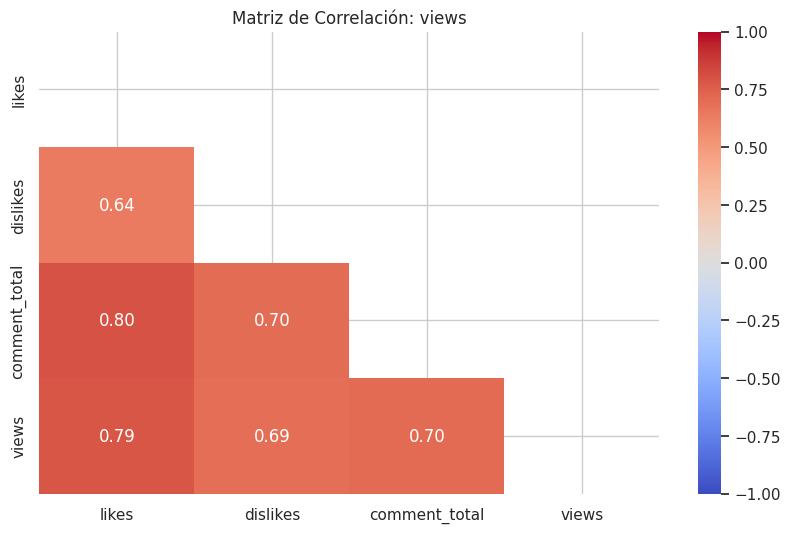

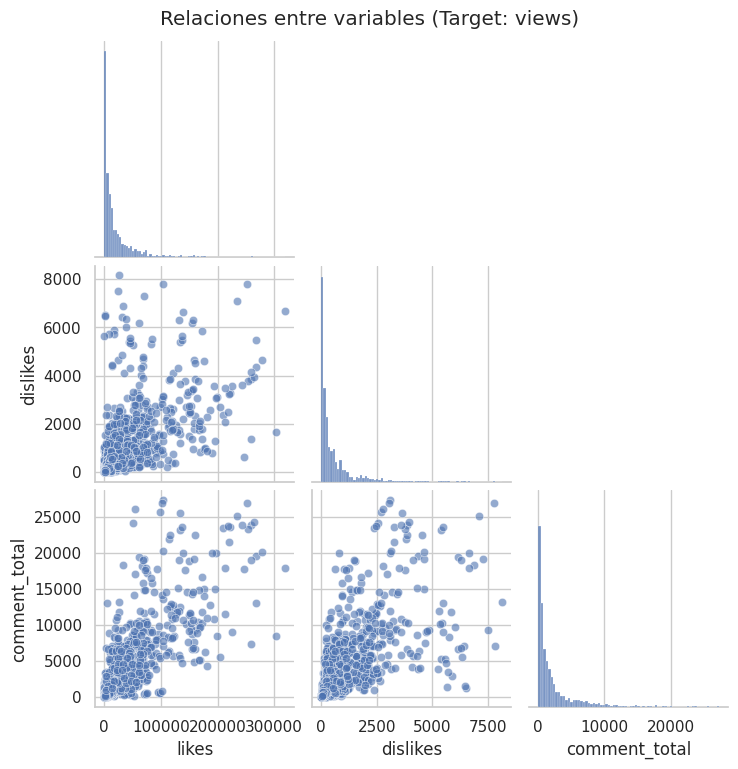

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

def visualizar_grid_dinamico(df, features, target, tipo_target='continuo'):
    print(f"--- GENERANDO GRAFICOS PARA TARGET: {target} ({tipo_target.upper()}) ---")
    
    sns.set_theme(style="whitegrid")
    cols_totales = features + [target]
    df_plot = df[cols_totales].copy()
    
    if len(df_plot) > 2000:
        df_plot = df_plot.sample(2000, random_state=42)
    
    plt.figure(figsize=(10, 6))
    corr = df_plot.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
    plt.title(f"Matriz de Correlación: {target}")
    plt.show()

    if tipo_target == 'discreto':
        sns.pairplot(df_plot, vars=features, hue=target, palette='viridis', corner=True)
    else:
        g = sns.pairplot(df_plot, vars=features, corner=True, plot_kws={'alpha': 0.6})
        g.fig.suptitle(f"Relaciones entre variables (Target: {target})", y=1.02)
    
    plt.show()

### SE PROPONE USAR EL TARGET VIEWS PARA ANALIZAR SU RELACIÓN CON LIKES, DISLIKES Y COMMENT_TOTAL (REGRESIÓN CONTINUA)
visualizar_grid_dinamico(df, ['likes', 'dislikes', 'comment_total'], 'views', 'continuo')

In [18]:
#creamos las nuevas variables
df["interaction"] = df["comment_total"] / (df["likes"] + 1)

p33 = df["interaction"].quantile(0.33)
p66 = df["interaction"].quantile(0.66)

def clasificar_interaccion(x):
    if x <= p33:
        return "Baja"
    elif x <= p66:
        return "Aceptable"
    else:
        return "Alta"

df["target"] = df["interaction"].apply(clasificar_interaccion)




#### SE PROPONE UNA VARIABLE TARGET "VIRALIDAD" DE CLASIFICACIÓN DISCRETA BASADA EN EL PERCENTIL DE VISTAS 
umbral = df['views'].quantile(0.85)
df['target_viral'] = (df['views'] > umbral).astype(int)

In [19]:
df.category_id.value_counts()

category_id
24    1374
10    1142
26    1133
22    1103
17     671
23     488
1      376
25     262
20     249
28     248
27     210
15      78
2       63
19      46
29       5
Name: count, dtype: int64

In [20]:
df[["likes", "comment_total"]].corr()

,likes,comment_total
likes,1.000000,0.798946
comment_total,0.798946,1.000000


## Segmentación de sets

In [21]:
# Variable objetivo discreta
tgt = "target"
vars_pred = [x for x in df.columns if x not in [tgt]]

In [22]:
X = df[vars_pred]
y = df[tgt]

## Modelado


Dentro de la clase de Modelado se encuentran los pipelines de regresión y clasificación, el split de entrenamiento y pruebas es 80-20

Para el campo de texto "tags" se elimina ruido de palabras inglesas que corresponden a nexos o conectores (and, or, the, etc.)

Se obtienen los 20 tags mas representativos que se usaran como elementos de los modelos de regresión.

Se usa la metrica R2 para problemas de regresión y Accuracy para problemas de clasificación (se pueden agregar nuevas)

Las funciones permiten el entrenamiento haciendo uso de GridSearch CV (CV=5) y RandomizedSearchCV, devuelve el mejor modelo de acuerdo a la metrica especificada y guarda los modelos en objetos para su uso posterior.


In [23]:
class Modelado:
    def __init__(self, df, target, num_feats, txt_feat, tipo_problema='regresion'):
        self.df = df
        self.target = target
        self.num_feats = num_feats
        self.txt_feat = txt_feat
        self.tipo_problema = tipo_problema
        
        self.resultados = []           
        self.modelos_entrenados = {}   
        
        X = self.df[self.num_feats + [self.txt_feat]]
        y = self.df[self.target]
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    def _crear_pipeline(self, modelo):
        limpiar_sep = lambda x: x.str.replace('|', ' ', regex=False)  # Separadores presentes en la columna de tags
        

        tfidf = TfidfVectorizer(stop_words='english', max_features=20)

        preprocessor = ColumnTransformer(
            transformers=[
                ('num', Pipeline([
                    ('imputer', SimpleImputer(strategy='median')),
                    ('scaler', StandardScaler())
                ]), self.num_feats),
                ('txt', Pipeline([
                    ('cleaner', FunctionTransformer(limpiar_sep, validate=False)),
                    ('tfidf', tfidf)
                ]), self.txt_feat)
            ],
            sparse_threshold=0 
        )
        
        return Pipeline([
            ('preprocessor', preprocessor),
            ('modelo', modelo)
        ])

    def ejecutar_auditoria(self, configs, estrategia='grid'):
        print(f"=== INICIANDO AUDITORÍA ({estrategia.upper()}) ===")
        scoring = 'r2' if self.tipo_problema == 'regresion' else 'accuracy'
        
        for nombre, cfg in configs.items():
            print(f"> Procesando: {nombre}...")
            pipe = self._crear_pipeline(cfg['model'])
            
            params = cfg['params'].copy()
            params['preprocessor__num__scaler'] = [StandardScaler(), RobustScaler()]
            
            try:
                if estrategia == 'grid':
                    search = GridSearchCV(pipe, params, cv=5, scoring=scoring, n_jobs=-1)
                else:
                    search = RandomizedSearchCV(pipe, params, n_iter=10, cv=5, scoring=scoring, n_jobs=-1)
                
                search.fit(self.X_train, self.y_train)
                
                self._guardar_metricas(nombre, search)
                
                self.modelos_entrenados[nombre] = search.best_estimator_
                
            except Exception as e:
                print(f"   [ERROR] {nombre}: {str(e)[:100]}")

    def _guardar_metricas(self, nombre, search):
        best = search.best_estimator_
        scaler = type(best.named_steps['preprocessor'].named_transformers_['num'].named_steps['scaler']).__name__
        
        y_pred = best.predict(self.X_test)
        
        if self.tipo_problema == 'regresion':
            metric = r2_score(self.y_test, y_pred)
            lbl = "R2"
        else:
            metric = accuracy_score(self.y_test, y_pred)
            lbl = "Acc"
            
        mejores_params = str(search.best_params_).replace('preprocessor__num__scaler', '').replace('modelo__', '')

        self.resultados.append({
            'Algoritmo': nombre,
            'Escalador': scaler,
            f'Test {lbl}': round(metric, 4),
            'Params': mejores_params
        })

    def obtener_tabla(self):
        if not self.resultados:
            return pd.DataFrame()
        return pd.DataFrame(self.resultados).sort_values(by=list(self.resultados[0].keys())[2], ascending=False)


In [24]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)

class Performance:
    def __init__(self, df, target, num_feats, txt_feat, tipo_problema='regresion'):
        self.df = df
        self.target = target
        self.num_feats = num_feats
        self.txt_feat = txt_feat
        self.tipo_problema = tipo_problema
        
        # Almacenamiento
        self.historial_completo = []   # Dataframes de resultados crudos
        self.modelos_entrenados = {}   # Objetos (Pipelines) ajustados
        
        # Split
        X = self.df[self.num_feats + [self.txt_feat]]
        y = self.df[self.target]
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    def _crear_pipeline(self, modelo):
        """Pipeline con Fix LARS (matriz densa) y Stopwords"""
        limpiar_sep = lambda x: x.str.replace('|', ' ', regex=False)
        tfidf = TfidfVectorizer(stop_words='english', max_features=20)

        preprocessor = ColumnTransformer(
            transformers=[
                ('num', Pipeline([
                    ('imputer', SimpleImputer(strategy='median')),
                    ('scaler', StandardScaler()) # Placeholder
                ]), self.num_feats),
                ('txt', Pipeline([
                    ('cleaner', FunctionTransformer(limpiar_sep, validate=False)),
                    ('tfidf', tfidf)
                ]), self.txt_feat)
            ],
            sparse_threshold=0 # Vital para LARS/Bayesiana
        )
        return Pipeline([('preprocessor', preprocessor), ('modelo', modelo)])

    def ejecutar_auditoria(self, configs, estrategia='grid', n_iter_random=10):
        print(f"=== EJECUTANDO PERFORMANCE ({estrategia.upper()}) ===")
        scoring = 'r2' if self.tipo_problema == 'regresion' else 'accuracy'
        
        for nombre, cfg in configs.items():
            print(f"> Entrenando: {nombre}...")
            pipe = self._crear_pipeline(cfg['model'])
            params = cfg['params'].copy()
            params['preprocessor__num__scaler'] = [StandardScaler(), RobustScaler()]
            
            if estrategia == 'grid':
                search = GridSearchCV(pipe, params, cv=5, scoring=scoring, n_jobs=-1)
            else:
                search = RandomizedSearchCV(pipe, params, n_iter=n_iter_random, cv=5, scoring=scoring, n_jobs=-1, random_state=42)
            
            search.fit(self.X_train, self.y_train)
            
            # 1. Guardar Historial Completo
            df_res = pd.DataFrame(search.cv_results_)
            # Limpieza de columnas
            cols_params = [c for c in df_res.columns if 'param_' in c]
            cols_utiles = cols_params + ['mean_test_score', 'std_test_score']
            df_temp = df_res[cols_utiles].copy()
            df_temp['Algoritmo'] = nombre
            df_temp['Estrategia'] = estrategia
            df_temp.columns = [c.replace('param_', '').replace('modelo__', '').replace('preprocessor__num__', '') for c in df_temp.columns]
            
            self.historial_completo.append(df_temp)
            
            # 2. Guardar Mejor Modelo
            self.modelos_entrenados[nombre] = search.best_estimator_

    def obtener_ranking(self, top_n=None):
        """Retorna el ranking consolidado. Si top_n es None, retorna todo."""
        if not self.historial_completo:
            return pd.DataFrame()
        
        df_total = pd.concat(self.historial_completo, ignore_index=True)
        
        # Ordenar columnas
        cols_fijas = ['Algoritmo', 'mean_test_score', 'std_test_score', 'scaler']
        cols_vars = [c for c in df_total.columns if c not in cols_fijas and c != 'Estrategia']
        df_final = df_total[cols_fijas + cols_vars].sort_values(by='mean_test_score', ascending=False)
        
        if top_n:
            return df_final.head(top_n)
        return df_final

    def diagnostico_mejor_modelo(self):
        """Analiza a profundidad el modelo ganador #1 del ranking"""
        ranking = self.obtener_ranking()
        if ranking.empty: return
        
        mejor_nombre = ranking.iloc[0]['Algoritmo']
        mejor_modelo = self.modelos_entrenados[mejor_nombre]
        
        print(f"\n{'='*40}")
        print(f"ANÁLISIS DEL GANADOR: {mejor_nombre.upper()}")
        print(f"{'='*40}")
        
        # 1. Cross Validation en Train (Robustez)
        scores_cv = cross_val_score(mejor_modelo, self.X_train, self.y_train, cv=5, scoring='r2' if self.tipo_problema == 'regresion' else 'accuracy')
        print(f"1. Validación Cruzada (Train - 5 Folds):")
        print(f"   Media: {scores_cv.mean():.4f} | Desv. Std: {scores_cv.std():.4f}")
        print(f"   Scores individuales: {scores_cv}")
        
        # 2. Evaluación Final en Test (Generalización)
        y_pred = mejor_modelo.predict(self.X_test)
        if self.tipo_problema == 'regresion':
            score_test = r2_score(self.y_test, y_pred)
            lbl = "R2"
        else:
            score_test = accuracy_score(self.y_test, y_pred)
            lbl = "Accuracy"
        print(f"\n2. Score Final en TEST Set ({lbl}): {score_test:.4f}")

        # 3. Gráficas
        self._graficar_prediccion_vs_real(self.y_test, y_pred, mejor_nombre)
        self._graficar_grid_coeficientes()

    def _graficar_prediccion_vs_real(self, y_true, y_pred, titulo):
        plt.figure(figsize=(8, 6))
        if self.tipo_problema == 'regresion':
            # Scatter Plot
            plt.scatter(y_true, y_pred, alpha=0.6, color='royalblue', edgecolors='k')
            plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2) # Línea ideal
            plt.xlabel('Valor Real')
            plt.ylabel('Valor Predicho')
            plt.title(f'Regresión: Real vs Predicho ({titulo})')
            plt.grid(True, alpha=0.3)
        else:
            # Confusion Matrix
            cm = confusion_matrix(y_true, y_pred)
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
            plt.xlabel('Predicho')
            plt.ylabel('Real')
            plt.title(f'Matriz de Confusión ({titulo})')
        plt.show()

    def _graficar_grid_coeficientes(self, top_n=10):
        """Genera la cuadrícula de coeficientes de todos los modelos entrenados"""
        modelos = self.modelos_entrenados
        n_modelos = len(modelos)
        cols = 3
        rows = math.ceil(n_modelos / cols)
        
        fig, axes = plt.subplots(rows, cols, figsize=(18, 4 * rows), constrained_layout=True)
        if n_modelos > 1: axes = axes.flatten()
        else: axes = [axes]
        
        for i, (nombre, pipe) in enumerate(modelos.items()):
            ax = axes[i]
            # Extraer features
            try:
                txt_cols = pipe.named_steps['preprocessor'].named_transformers_['txt']['tfidf'].get_feature_names_out()
                feats = np.array(self.num_feats + list(txt_cols))
            except: feats = np.array(self.num_feats)
            
            # Extraer pesos
            modelo_core = pipe.named_steps['modelo']
            if hasattr(modelo_core, 'coef_'):
                coefs = modelo_core.coef_
                if coefs.ndim > 1: coefs = coefs[0]
                
                df_w = pd.DataFrame({'F': feats, 'W': coefs})
                df_w['Abs'] = df_w['W'].abs()
                df_top = df_w.sort_values(by='Abs', ascending=False).head(top_n)
                
                colors = ['#2ca02c' if x > 0 else '#d62728' for x in df_top['W']]
                sns.barplot(data=df_top, x='W', y='F', ax=ax, palette=colors)
                ax.set_title(nombre)
                ax.axvline(0, color='k', linestyle='--', lw=0.5)
                ax.set_xlabel('')
                ax.set_ylabel('')
            else:
                ax.text(0.5, 0.5, "Sin Coeficientes Lineales", ha='center')
                ax.set_title(nombre)
        
        # Limpiar huecos vacíos
        for j in range(i + 1, len(axes)): axes[j].axis('off')
        plt.suptitle("Grid de Coeficientes (Feature Importance)", fontsize=16, y=1.05)
        plt.show()

In [25]:
##### AQUI SE CONFIGURA EL GRID DE PARAMETROS PARA CADA MODELO #####

config_reg_grid = {
    'Ridge': {'model': Ridge(), 'params': {'modelo__alpha': np.logspace(-2, 2, 5)}},
    'Lasso': {'model': Lasso(), 'params': {'modelo__alpha': np.logspace(-4, 0, 5)}},
    'ElasticNet': {'model': ElasticNet(), 'params': {'modelo__alpha': np.logspace(-3, 1, 5), 'modelo__l1_ratio': [0.1, 0.5, 0.9]}},
    'LARS': {'model': Lars(), 'params': {'modelo__n_nonzero_coefs': [5, 10, 15]}},
    'Bayesiana': {'model': BayesianRidge(), 'params': {'modelo__max_iter': [300]}}
}


In [26]:
### EJECUCION PARA GRID PERSONALIZADO
auditor_reg = Performance(df, 'views', ['likes', 'dislikes', 'comment_total'], 'tags', 'regresion')

# ESCENARIO 1: Grid Search
print("\n>>> Ejecutando Escenario 1: Grid Search...")
auditor_reg.ejecutar_auditoria(config_reg_grid, estrategia='grid')


>>> Ejecutando Escenario 1: Grid Search...
=== EJECUTANDO PERFORMANCE (GRID) ===
> Entrenando: Ridge...
> Entrenando: Lasso...
> Entrenando: ElasticNet...
> Entrenando: LARS...
> Entrenando: Bayesiana...


In [27]:
# EJECUCION PARA RANDOMIZED SEARCH

config_reg_random = {
    'Ridge': {'model': Ridge(), 'params': {'modelo__alpha': loguniform(1e-2, 1e2)}},
    'Lasso': {'model': Lasso(), 'params': {'modelo__alpha': loguniform(1e-4, 1e0)}},
    'ElasticNet': {'model': ElasticNet(), 'params': {'modelo__alpha': loguniform(1e-3, 1e1), 'modelo__l1_ratio': uniform(0.1, 0.8)}}, # ratio 0.1 a 0.9
    'LARS': {'model': Lars(), 'params': {'modelo__n_nonzero_coefs': randint(2, 20)}},
    'Bayesiana': {'model': BayesianRidge(), 'params': {'modelo__alpha_1': loguniform(1e-7, 1e-4)}}
}


print(">>> Ejecutando Escenario 2: Random Search...")
auditor_reg.ejecutar_auditoria(config_reg_random, estrategia='random', n_iter_random=20)

>>> Ejecutando Escenario 2: Random Search...
=== EJECUTANDO PERFORMANCE (RANDOM) ===
> Entrenando: Ridge...
> Entrenando: Lasso...
> Entrenando: ElasticNet...
> Entrenando: LARS...
> Entrenando: Bayesiana...


In [28]:

# Usamos LogisticRegression con distintos 'penalties' para simular Ridge/Lasso
config_cls_grid = {
    'Logistica (L2)': {'model': LogisticRegression(solver='liblinear', penalty='l2'), 'params': {'modelo__C': np.logspace(-3, 2, 5)}},
    'Logistica (L1)': {'model': LogisticRegression(solver='liblinear', penalty='l1'), 'params': {'modelo__C': np.logspace(-3, 1, 5)}}
}

auditor_cls = Performance(df, 'target_viral', ['likes', 'dislikes', 'comment_total'], 'tags', 'clasificacion')

# ESCENARIO 1: Grid Search
print("\n>>> Ejecutando Escenario 3: Grid Search...")
auditor_cls.ejecutar_auditoria(config_cls_grid, estrategia='grid')




>>> Ejecutando Escenario 3: Grid Search...
=== EJECUTANDO PERFORMANCE (GRID) ===
> Entrenando: Logistica (L2)...
> Entrenando: Logistica (L1)...


In [29]:
### EJECUCION PARA RANDOM

config_cls_random = {
    'Logistica (L2)': {'model': LogisticRegression(solver='liblinear', penalty='l2'), 'params': {'modelo__C': loguniform(1e-3, 1e2)}},
    'Logistica (L1)': {'model': LogisticRegression(solver='liblinear', penalty='l1'), 'params': {'modelo__C': loguniform(1e-3, 1e1)}}
}

# ESCENARIO 2: Random Search
print(">>> Ejecutando Escenario 4: Random Search...")
auditor_cls.ejecutar_auditoria(config_cls_random, estrategia='random', n_iter_random=20)


>>> Ejecutando Escenario 4: Random Search...
=== EJECUTANDO PERFORMANCE (RANDOM) ===
> Entrenando: Logistica (L2)...
> Entrenando: Logistica (L1)...


## EVALUACION DE MODELOS


--- RANKING FINAL REGRESIÓN (Top 5) ---


,Algoritmo,mean_test_score,std_test_score,scaler,alpha,l1_ratio,n_nonzero_coefs,max_iter,alpha_1
114,ElasticNet,0.681106,0.040187,StandardScaler(),0.003077,0.496142,NaN,NaN,NaN
64,Ridge,0.681101,0.040128,RobustScaler(),6.796578,NaN,NaN,NaN,NaN
30,ElasticNet,0.681101,0.040103,StandardScaler(),0.010000,0.900000,NaN,NaN,NaN
105,ElasticNet,0.681099,0.040094,StandardScaler(),0.001067,0.118450,NaN,NaN,NaN
20,ElasticNet,0.681097,0.040087,StandardScaler(),0.001000,0.100000,NaN,NaN,NaN



--- DIAGNÓSTICO DEL MEJOR MODELO (Regresión) ---

ANÁLISIS DEL GANADOR: ELASTICNET
1. Validación Cruzada (Train - 5 Folds):
   Media: 0.6811 | Desv. Std: 0.0402
   Scores individuales: [0.75506023 0.68083292 0.65754043 0.67598062 0.63611783]

2. Score Final en TEST Set (R2): 0.6699


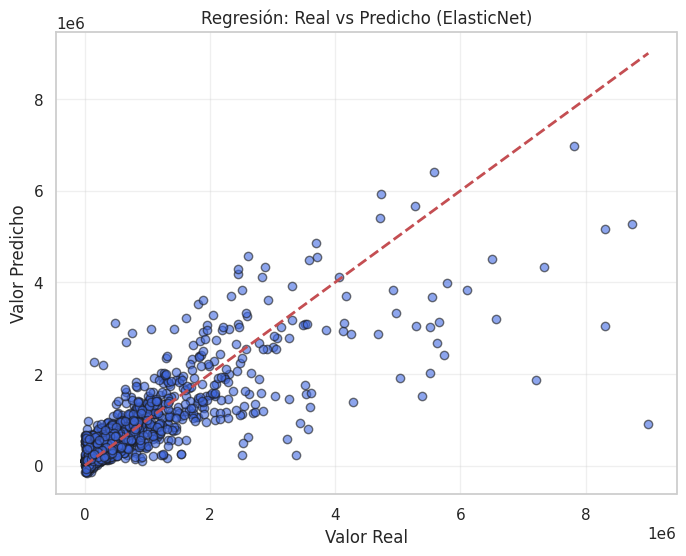

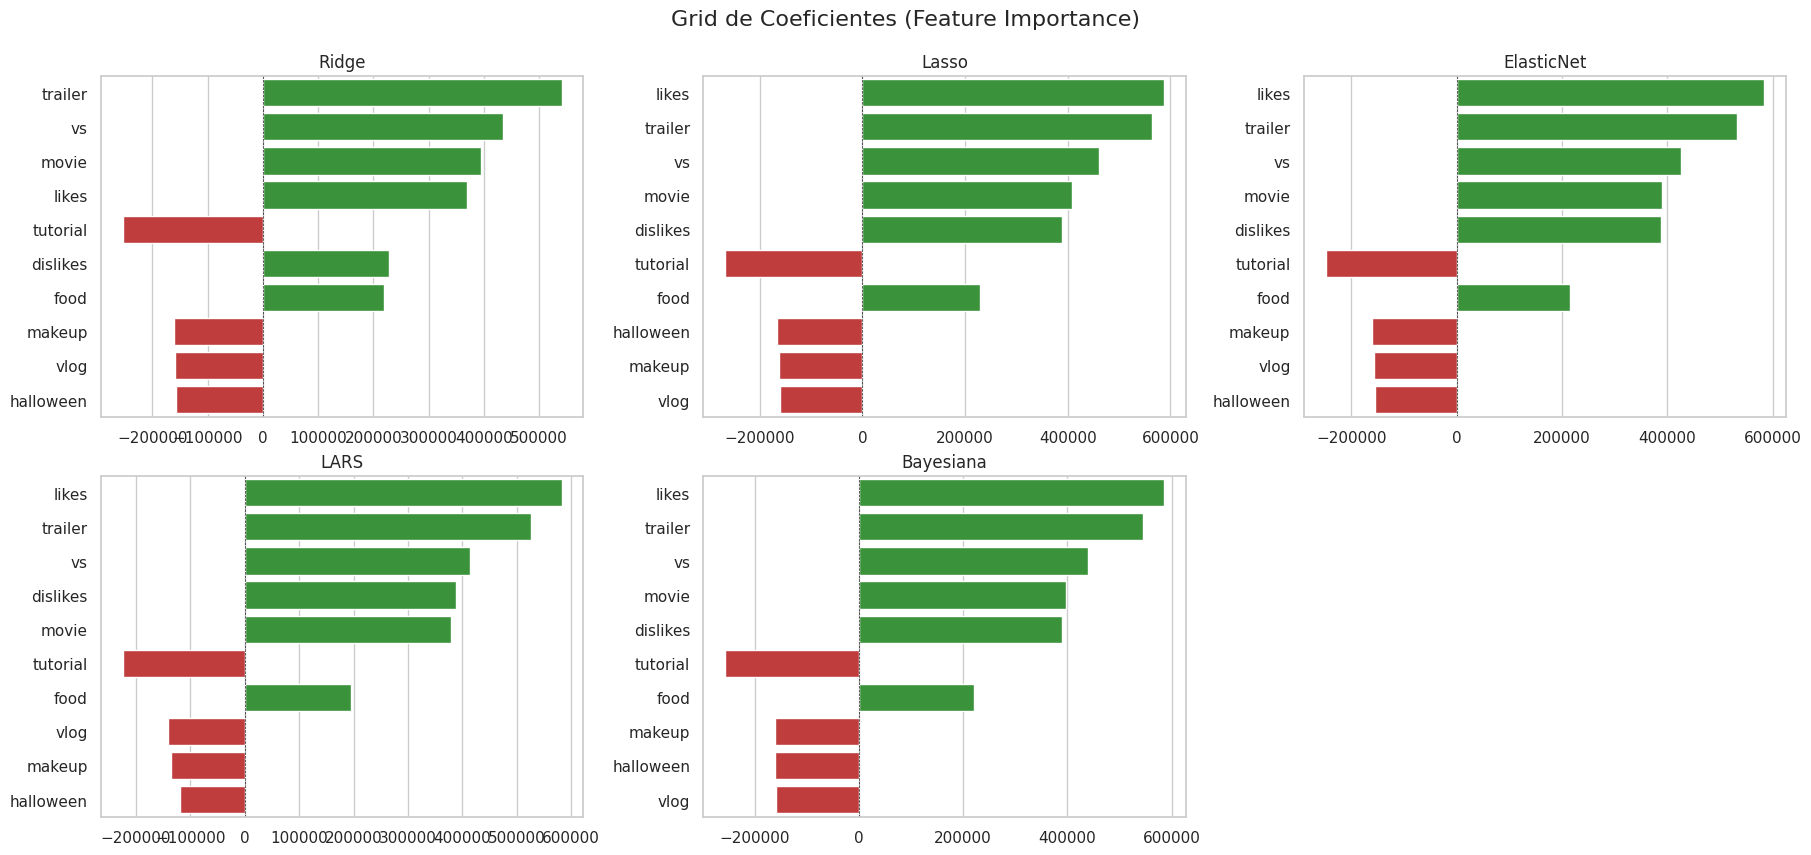

In [30]:
# RESULTADOS REGRESIÓN
print("\n--- RANKING FINAL REGRESIÓN (Top 5) ---")
ranking_reg = auditor_reg.obtener_ranking(top_n=5)
display(ranking_reg)

print("\n--- DIAGNÓSTICO DEL MEJOR MODELO (Regresión) ---")
auditor_reg.diagnostico_mejor_modelo()


--- RANKING FINAL CLASIFICACIÓN (Top 5) ---


,Algoritmo,mean_test_score,std_test_score,scaler,C
4,Logistica (L2),0.927827,0.006129,StandardScaler(),0.316228
38,Logistica (L2),0.927827,0.006288,RobustScaler(),0.372539
39,Logistica (L2),0.927660,0.005556,StandardScaler(),0.215682
5,Logistica (L2),0.927659,0.006296,RobustScaler(),0.316228
33,Logistica (L2),0.927659,0.006296,StandardScaler(),0.420604



--- DIAGNÓSTICO DEL MEJOR MODELO (Clasificación) ---

ANÁLISIS DEL GANADOR: LOGISTICA (L2)
1. Validación Cruzada (Train - 5 Folds):
   Media: 0.9278 | Desv. Std: 0.0063
   Scores individuales: [0.93959732 0.92114094 0.92785235 0.92443325 0.92611251]

2. Score Final en TEST Set (Accuracy): 0.9322


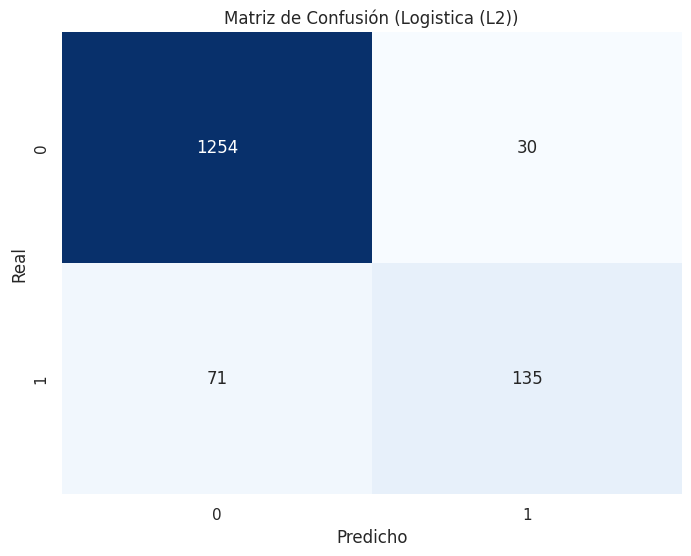

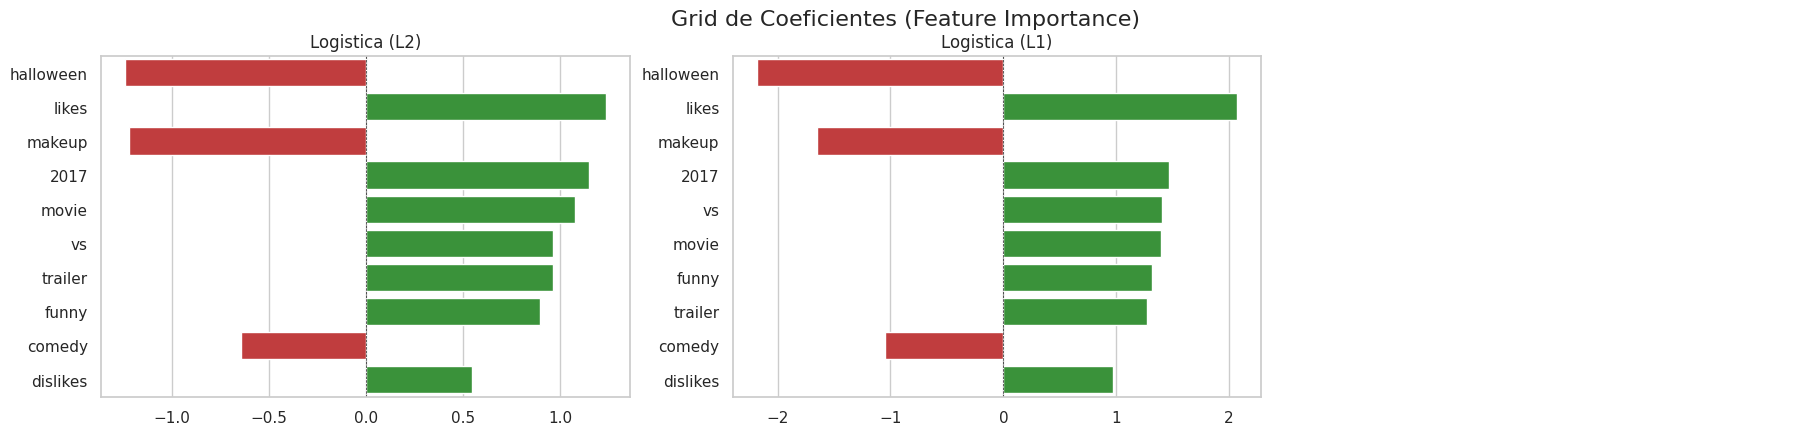

In [31]:
# RESULTADOS CLASIFICACIÓN
print("\n--- RANKING FINAL CLASIFICACIÓN (Top 5) ---")
ranking_cls = auditor_cls.obtener_ranking(top_n=5)
display(ranking_cls)

print("\n--- DIAGNÓSTICO DEL MEJOR MODELO (Clasificación) ---")
auditor_cls.diagnostico_mejor_modelo()

In [32]:
from sklearn import set_config
from IPython.display import display

def radiografia_del_ganador(auditor_obj):

    ranking = auditor_obj.obtener_ranking()
    if ranking.empty:
        print("No hay modelos entrenados en este auditor.")
        return
    
    nombre_ganador = ranking.iloc[0]['Algoritmo']
    score_ganador = ranking.iloc[0]['mean_test_score']
    pipeline_ganador = auditor_obj.modelos_entrenados[nombre_ganador]
    
    print(f"MODELO GANADOR: {nombre_ganador.upper()}")
    print(f"Score Promedio (CV): {score_ganador:.4f}")
    
    print("\n" + "="*60)
    print(" 1. ARQUITECTURA DEL PIPELINE ")
    print("="*60)
    print("Haz clic en los bloques abajo para ver detalles (ej. qué escalador se usó):")
    set_config(display='diagram') 
    display(pipeline_ganador)
    
    # hIPERPARÁMETROS
    print("\n" + "="*60)
    print(" 2. HIPERPARÁMETROS OPTIMIZADOS ")
    print("="*60)
    params = pipeline_ganador.get_params()
    params_limpios = {k: v for k, v in params.items() 
                      if ('modelo__' in k or 'scaler' in k) and not k.endswith('__steps')}
    
    df_params = pd.DataFrame.from_dict(params_limpios, orient='index', columns=['Valor Seleccionado'])
    display(df_params)
    
    # ECUACIÓN DEL MODELO (COEFICIENTES E INTERCEPTO)
    print("\n" + "="*60)
    print(" 3. ECUACIÓN MATEMÁTICA (Variables -> Predicción) ")
    print("="*60)
    
    modelo_final = pipeline_ganador.named_steps['modelo']
    
    if hasattr(modelo_final, 'intercept_'):
        intercepto = modelo_final.intercept_
        if isinstance(intercepto, np.ndarray): intercepto = intercepto[0]
        print(f"🔹 INTERCEPTO (Bias): {intercepto:.4f}")
        print("   (Es el valor base de la predicción cuando todas las variables son 0)")
    else:
        print("🔹 Este modelo no tiene intercepto lineal simple.")

    if hasattr(modelo_final, 'coef_'):
        feats_num = auditor_obj.num_feats
        
        try:
            # Accedemos: Pipeline -> Preprocessor -> Transformer 'txt' -> Pipeline Txt -> TFIDF
            tfidf_step = pipeline_ganador.named_steps['preprocessor'].named_transformers_['txt']['tfidf']
            feats_txt = list(tfidf_step.get_feature_names_out())
        except:
            feats_txt = [f"text_feature_{i}" for i in range(20)]
            
        nombres_variables = feats_num + feats_txt
        
        coefs = modelo_final.coef_
        if coefs.ndim > 1: coefs = coefs[0] 
        
        if len(nombres_variables) == len(coefs):
            df_ecuacion = pd.DataFrame({
                'Variable': nombres_variables,
                'Peso (Coeficiente)': coefs,
                'Impacto Absoluto': np.abs(coefs)
            })
            
            df_ecuacion = df_ecuacion.sort_values(by='Impacto Absoluto', ascending=False).reset_index(drop=True)
            
            print("\n🔹 TABLA DE COEFICIENTES (Top 15 más influyentes):")
            display(df_ecuacion.head(15))
            
            print("\nInterpretación:")
            print("- Peso Positivo: Aumenta el valor objetivo (Views/Viralidad).")
            print("- Peso Negativo: Disminuye el valor objetivo.")
            print("- Magnitud: Qué tan fuerte es el efecto.")
        else:
            print(f"⚠ Disparidad de dimensiones: {len(nombres_variables)} nombres vs {len(coefs)} coeficientes.")
    else:
        print("\n⚠ Este algoritmo no es lineal (no usa coeficientes directos).")


radiografia_del_ganador(auditor_reg)

MODELO GANADOR: ELASTICNET
Score Promedio (CV): 0.6811

 1. ARQUITECTURA DEL PIPELINE 
Haz clic en los bloques abajo para ver detalles (ej. qué escalador se usó):


,steps,"[('preprocessor', ...), ('modelo', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('txt', ...)]"
,remainder,'drop'
,sparse_threshold,0
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True



 2. HIPERPARÁMETROS OPTIMIZADOS 


,Valor Seleccionado
preprocessor__num__scaler,StandardScaler()
preprocessor__num__scaler__copy,True
preprocessor__num__scaler__with_mean,True
preprocessor__num__scaler__with_std,True
modelo__alpha,0.003077
modelo__copy_X,True
modelo__fit_intercept,True
modelo__l1_ratio,0.496142
modelo__max_iter,1000
modelo__positive,False



 3. ECUACIÓN MATEMÁTICA (Variables -> Predicción) 
🔹 INTERCEPTO (Bias): 669344.6461
   (Es el valor base de la predicción cuando todas las variables son 0)

🔹 TABLA DE COEFICIENTES (Top 15 más influyentes):


,Variable,Peso (Coeficiente),Impacto Absoluto
0,likes,583684.679539,583684.679539
1,trailer,532388.352354,532388.352354
2,vs,426628.652033,426628.652033
3,movie,389998.245158,389998.245158
4,dislikes,388893.587869,388893.587869
5,tutorial,-248412.321525,248412.321525
6,food,216224.664184,216224.664184
7,makeup,-160353.556625,160353.556625
8,vlog,-157480.377931,157480.377931
9,halloween,-155101.881643,155101.881643



Interpretación:
- Peso Positivo: Aumenta el valor objetivo (Views/Viralidad).
- Peso Negativo: Disminuye el valor objetivo.
- Magnitud: Qué tan fuerte es el efecto.


In [33]:
from sklearn import set_config
from IPython.display import display

def radiografia_del_ganador(auditor_obj):
    
    ranking = auditor_obj.obtener_ranking()
    if ranking.empty:
        print("No hay modelos entrenados en este auditor.")
        return
    
    nombre_ganador = ranking.iloc[0]['Algoritmo']
    score_ganador = ranking.iloc[0]['mean_test_score']
    pipeline_ganador = auditor_obj.modelos_entrenados[nombre_ganador]
    
    print(f"MODELO GANADOR: {nombre_ganador.upper()}")
    print(f"Score Promedio (CV): {score_ganador:.4f}")
    
    print("\n" + "="*60)
    print(" 1. ARQUITECTURA DEL PIPELINE ")
    print("="*60)
    print("Haz clic en los bloques abajo para ver detalles (ej. qué escalador se usó):")
    set_config(display='diagram') 
    display(pipeline_ganador)
    
    # hIPERPARÁMETROS
    print("\n" + "="*60)
    print(" 2. HIPERPARÁMETROS OPTIMIZADOS ")
    print("="*60)
    params = pipeline_ganador.get_params()
    params_limpios = {k: v for k, v in params.items() 
                      if ('modelo__' in k or 'scaler' in k) and not k.endswith('__steps')}
    
    df_params = pd.DataFrame.from_dict(params_limpios, orient='index', columns=['Valor Seleccionado'])
    display(df_params)
    
    # ECUACIÓN DEL MODELO (COEFICIENTES E INTERCEPTO)
    print("\n" + "="*60)
    print(" 3. ECUACIÓN MATEMÁTICA (Variables -> Predicción) ")
    print("="*60)
    
    modelo_final = pipeline_ganador.named_steps['modelo']
    
    if hasattr(modelo_final, 'intercept_'):
        intercepto = modelo_final.intercept_
        if isinstance(intercepto, np.ndarray): intercepto = intercepto[0]
        print(f"🔹 INTERCEPTO (Bias): {intercepto:.4f}")
        print("   (Es el valor base de la predicción cuando todas las variables son 0)")
    else:
        print("🔹 Este modelo no tiene intercepto lineal simple.")

    if hasattr(modelo_final, 'coef_'):
        feats_num = auditor_obj.num_feats
        
        try:
            # Accedemos: Pipeline -> Preprocessor -> Transformer 'txt' -> Pipeline Txt -> TFIDF
            tfidf_step = pipeline_ganador.named_steps['preprocessor'].named_transformers_['txt']['tfidf']
            feats_txt = list(tfidf_step.get_feature_names_out())
        except:
            feats_txt = [f"text_feature_{i}" for i in range(20)]
            
        nombres_variables = feats_num + feats_txt
        
        coefs = modelo_final.coef_
        if coefs.ndim > 1: coefs = coefs[0] 
        
        if len(nombres_variables) == len(coefs):
            df_ecuacion = pd.DataFrame({
                'Variable': nombres_variables,
                'Peso (Coeficiente)': coefs,
                'Impacto Absoluto': np.abs(coefs)
            })
            
            df_ecuacion = df_ecuacion.sort_values(by='Impacto Absoluto', ascending=False).reset_index(drop=True)
            
            print("\n🔹 TABLA DE COEFICIENTES (Top 15 más influyentes):")
            display(df_ecuacion.head(15))
            
            print("\nInterpretación:")
            print("- Peso Positivo: Aumenta el valor objetivo (Views/Viralidad).")
            print("- Peso Negativo: Disminuye el valor objetivo.")
            print("- Magnitud: Qué tan fuerte es el efecto.")
        else:
            print(f"⚠ Disparidad de dimensiones: {len(nombres_variables)} nombres vs {len(coefs)} coeficientes.")
    else:
        print("\n⚠ Este algoritmo no es lineal (no usa coeficientes directos).")


radiografia_del_ganador(auditor_cls)

MODELO GANADOR: LOGISTICA (L2)
Score Promedio (CV): 0.9278

 1. ARQUITECTURA DEL PIPELINE 
Haz clic en los bloques abajo para ver detalles (ej. qué escalador se usó):


,steps,"[('preprocessor', ...), ('modelo', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('txt', ...)]"
,remainder,'drop'
,sparse_threshold,0
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True



 2. HIPERPARÁMETROS OPTIMIZADOS 


,Valor Seleccionado
preprocessor__num__scaler,RobustScaler()
preprocessor__num__scaler__copy,True
preprocessor__num__scaler__quantile_range,"(25.0, 75.0)"
preprocessor__num__scaler__unit_variance,False
preprocessor__num__scaler__with_centering,True
preprocessor__num__scaler__with_scaling,True
modelo__C,0.372539
modelo__class_weight,None
modelo__dual,False
modelo__fit_intercept,True



 3. ECUACIÓN MATEMÁTICA (Variables -> Predicción) 
🔹 INTERCEPTO (Bias): -3.7956
   (Es el valor base de la predicción cuando todas las variables son 0)

🔹 TABLA DE COEFICIENTES (Top 15 más influyentes):


,Variable,Peso (Coeficiente),Impacto Absoluto
0,halloween,-1.239167,1.239167
1,likes,1.232441,1.232441
2,makeup,-1.222050,1.222050
3,2017,1.145881,1.145881
4,movie,1.074346,1.074346
5,vs,0.962862,0.962862
6,trailer,0.961915,0.961915
7,funny,0.895742,0.895742
8,comedy,-0.643374,0.643374
9,dislikes,0.544894,0.544894



Interpretación:
- Peso Positivo: Aumenta el valor objetivo (Views/Viralidad).
- Peso Negativo: Disminuye el valor objetivo.
- Magnitud: Qué tan fuerte es el efecto.
